In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import torch
import torch.nn as nn
from rich import print

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/Kaggle_datasets/Deep_Learning_Datasets/neo.csv')

In [ ]:
df.shape

(90836, 10)

In [ ]:
df.head(20)

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True
5,54138696,(2021 GY23),0.036354,0.081291,34297.587778,4.058569e+07,Earth,False,24.32,False
6,54189957,(2021 PY40),0.171615,0.383743,27529.472307,2.906912e+07,Earth,False,20.95,False
7,54230078,(2021 XD6),0.005328,0.011914,57544.470083,5.511502e+07,Earth,False,28.49,False
8,2088213,88213 (2001 AF2),0.350393,0.783502,56625.210122,6.903598e+07,Earth,False,19.40,False
9,3766065,(2016 YM),0.105817,0.236614,48425.840329,3.835526e+07,Earth,False,22.00,False


In [ ]:
df.tail()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
90831,3763337,(2016 VX1),0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,3837603,(2019 AD3),0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,54017201,(2020 JP3),0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,54115824,(2021 CN5),0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False
90835,54205447,(2021 TW7),0.039862,0.089133,27024.455553,5.977213e+07,Earth,False,24.12,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [ ]:
df['id'].value_counts()

,count
id,
2277810,43
2469219,43
3743123,40
2138175,39
3893865,38
...,...
54268807,1
54265974,1
54271311,1


In [ ]:
df.describe()

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,1.438288e+07,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,2.087202e+07,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448110e+06,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,3.748362e+06,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


In [ ]:
cols_to_count = ["name", "orbiting_body", "sentry_object", "hazardous"]

for col in cols_to_count:
  print(f"---{col}---")
  print(df[col].value_counts())
  print("\n")

---name---

name
277810 (2006 FV35)               43
469219 Kamo`oalewa (2016 HO3)    43
(2016 CA138)                     40
138175 (2000 EE104)              39
(2019 XS)                        38
                                 ..
(2022 GY)                         1
(2022 FN3)                        1
(2022 GW3)                        1
(2022 GV3)                        1
(2022 GW2)                        1
Name: count, Length: 27423, dtype: int64

---orbiting_body---

orbiting_body
Earth    90836
Name: count, dtype: int64

---sentry_object---

sentry_object
False    90836
Name: count, dtype: int64

---hazardous---

hazardous
False    81996
True      8840
Name: count, dtype: int64

<Axes: xlabel='hazardous', ylabel='count'>

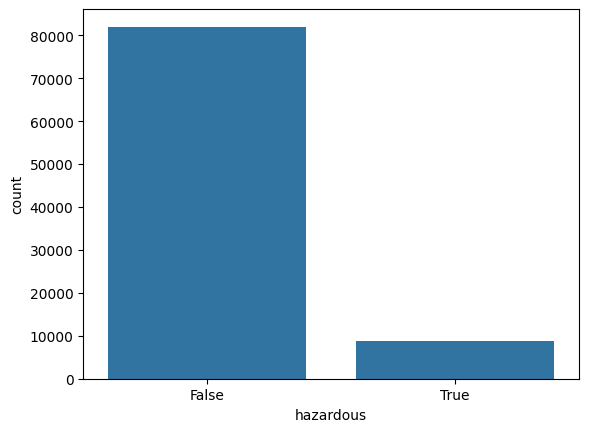

In [ ]:
sns.countplot(data = df, x = 'hazardous')

In [ ]:
df.isnull().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0
hazardous,0


In [ ]:
try:
  df = df.drop(['id', 'name', 'orbiting_body'], axis = 1)
except ValueError:
  print("Column is already removed")

In [ ]:
df.shape

(90836, 7)

In [ ]:
X = df.drop('hazardous', axis = 1)
y = df['hazardous'].copy()

In [ ]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size = 0.2, stratify = y_train_full, random_state = 42)

In [ ]:
print(f"Shape of X_train is: {X_train.shape}")
print(f"Shape of X_test is: {X_test.shape}")
print(f"Shape of X_valid is: {X_valid.shape}")

Shape of X_train is: (58134, 6)

Shape of X_test is: (18168, 6)

Shape of X_valid is: (14534, 6)

<Axes: xlabel='absolute_magnitude', ylabel='est_diameter_max'>

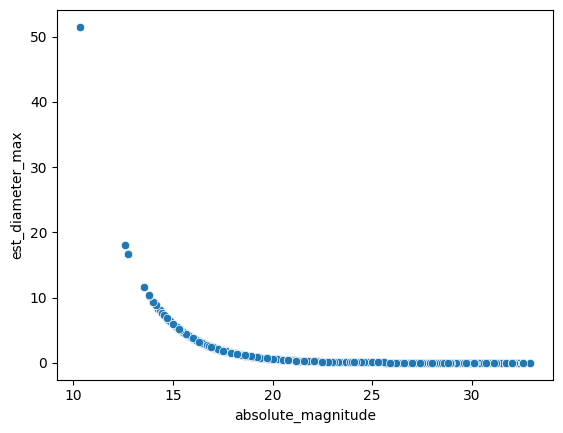

In [ ]:
sns.scatterplot(data = X_train, x = 'absolute_magnitude', y = 'est_diameter_max')

<Axes: xlabel='absolute_magnitude', ylabel='est_diameter_min'>

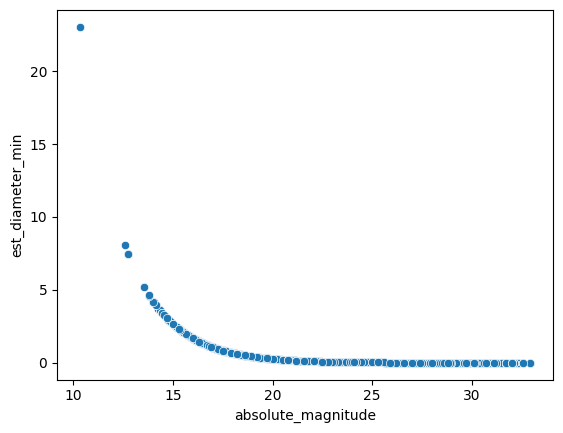

In [ ]:
sns.scatterplot(data = X_train, x = 'absolute_magnitude', y = 'est_diameter_min')

<Axes: xlabel='absolute_magnitude', ylabel='relative_velocity'>

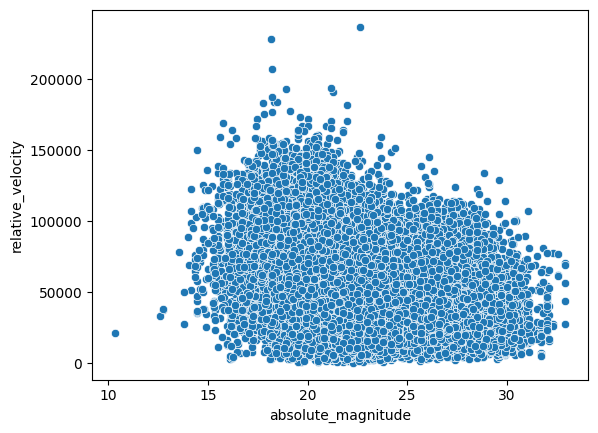

In [ ]:
sns.scatterplot(data = X_train, x = 'absolute_magnitude', y = 'relative_velocity')

<Axes: xlabel='est_diameter_max', ylabel='est_diameter_max'>

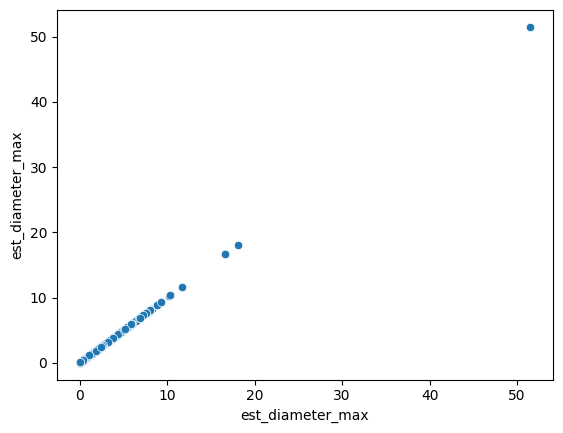

In [ ]:
sns.scatterplot(data = X_train, x = 'est_diameter_max', y = 'est_diameter_max')

<Axes: xlabel='miss_distance', ylabel='est_diameter_max'>

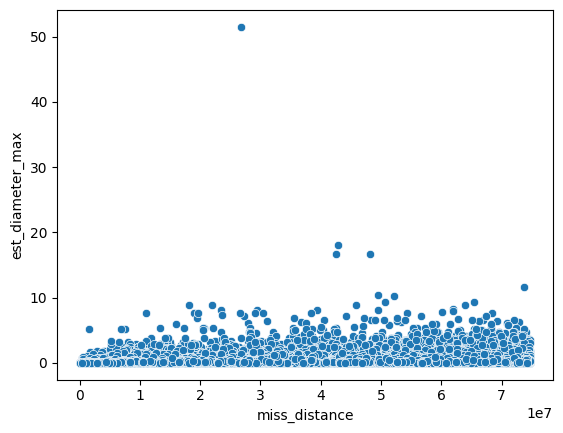

In [ ]:
sns.scatterplot(data = X_train, x = 'miss_distance', y = 'est_diameter_max')

<Axes: xlabel='absolute_magnitude', ylabel='miss_distance'>

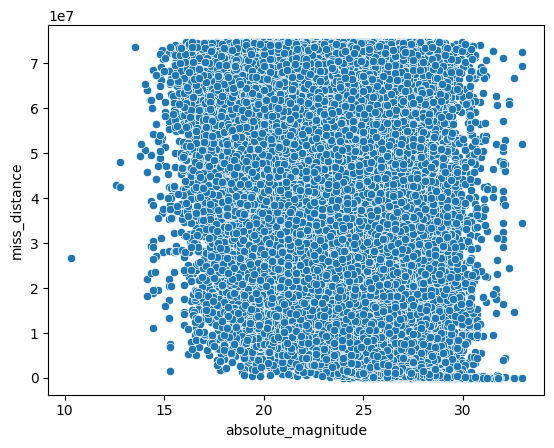

In [ ]:
sns.scatterplot(data = X_train, x = 'absolute_magnitude', y = 'miss_distance')

## **Data Cleaning**

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer()

In [ ]:
X_train_num = X_train.select_dtypes(exclude = 'object')

In [ ]:
X_train_num.shape

(58134, 6)

In [ ]:
X_train_num.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,sentry_object,absolute_magnitude
60700,0.042126,0.094198,37632.811817,1.217046e+07,False,24.0
86588,0.004411,0.009864,89923.374417,6.242582e+07,False,28.9
40420,0.002914,0.006517,97366.690876,4.279233e+07,False,29.8
19131,0.016771,0.037501,29700.565221,1.719991e+06,False,26.0
50948,0.167708,0.375008,64848.937625,2.637200e+07,False,21.0


In [ ]:
imputed = imputer.fit_transform(X_train_num)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_train_Scaled = scaler.fit_transform(X_train_num)

In [ ]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

In [ ]:
Preprocessing = ColumnTransformer([
    ('num', num_pipeline, X_train_num.columns)
])

In [ ]:
Preprocessing

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['est_diameter_min', 'est_diameter_max', 'relative_velocity',
       'miss_distance', 'sentry_object', 'absolute_magnitude'],
      dtype='object'))])

In [ ]:
if torch.cuda.is_available():
  device = "cuda"
elif torch.backends.mps.is_available():
  device = "mps"
else:
  device = "cpu"

In [ ]:
X_train_preprocessed = Preprocessing.fit_transform(X_train)
X_test_preprocessed = Preprocessing.fit_transform(X_test)
X_valid_preprocessed = Preprocessing.fit_transform(X_valid)

In [ ]:
X_train_preprocessed.dtype

dtype('float64')

In [ ]:
X_train = torch.FloatTensor(X_train_preprocessed)
X_test = torch.FloatTensor(X_test_preprocessed)
X_valid = torch.FloatTensor(X_valid_preprocessed)

In [ ]:
X_train.dtype

torch.float32

In [ ]:
y_train = torch.FloatTensor(y_train.values).reshape(-1, 1)
y_test = torch.FloatTensor(y_test.values).reshape(-1, 1)
y_valid = torch.FloatTensor(y_valid.values).reshape(-1, 1)

In [ ]:
y_train.dtype

torch.float32

In [ ]:
torch.manual_seed(42)
n_features = X_train.shape[1]
w = torch.randn(n_features, 1, requires_grad = True)
b = torch.randn(1, requires_grad = True)

In [ ]:
model = nn.Linear(in_features = n_features, out_features = 1)

In [ ]:
for param in model.parameters():
  print(param)

Parameter containing:
tensor([[ 0.3147,  0.0603, -0.1906,  0.1041, -0.1881, -0.0479]],
       requires_grad=True)

Parameter containing:
tensor([-0.1658], requires_grad=True)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)
valid_loader = DataLoader(valid_dataset, batch_size = 32)

In [ ]:
class NearestEarthObjClassification(nn.Module):
  def __init__(self, n_inputs, n_hidden1, n_hidden2, n_hidden3, n_classes):
    super().__init__()
    self.DNN = nn.Sequential(
        nn.Linear(n_inputs, n_hidden1),
        nn.ReLU(),
        nn.Linear(n_hidden1, n_hidden2),
        nn.ReLU(),
        nn.Linear(n_hidden2, n_hidden3),
        nn.ReLU(),
        nn.Linear(n_hidden3, n_classes)
    )
  def forward(self, X):
    return self.DNN(X)

In [ ]:
model = NearestEarthObjClassification(n_inputs = n_features, n_hidden1 = 100, n_hidden2 = 100, n_hidden3 = 100, n_classes = 1)

In [ ]:
torch.manual_seed(42)
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
BCE_loss = nn.BCEWithLogitsLoss()

In [ ]:
def train(model, optimizer, criterion, train_loader, n_epochs):
  model.train()
  for epoch in range(n_epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    mean_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}")

In [ ]:
n_epochs = 20
train(model, optimizer, BCE_loss, train_loader, n_epochs)

Epoch 1/20, Loss: 0.2658

Epoch 2/20, Loss: 0.2107

Epoch 3/20, Loss: 0.2023

Epoch 4/20, Loss: 0.1979

Epoch 5/20, Loss: 0.1952

...

Epoch 16/20, Loss: 0.1869

Epoch 17/20, Loss: 0.1866

Epoch 18/20, Loss: 0.1863

Epoch 19/20, Loss: 0.1861

Epoch 20/20, Loss: 0.1860

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 32.6 MB/s eta 0:00:00


In [ ]:
from torchmetrics import Accuracy

def evaluate(model, data_loader, criterion):
  model.eval()
  total_loss = 0
  # Initialize Accuracy metric
  accuracy_metric = Accuracy(task="binary", num_classes=1).to(device)

  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred_logits = model(X_batch)
      loss = criterion(y_pred_logits, y_batch)
      total_loss += loss.item()

      # Convert logits to probabilities, then to binary predictions for accuracy
      y_pred_probs = torch.sigmoid(y_pred_logits)
      y_pred_binary = (y_pred_probs >= 0.5).float()

      accuracy_metric.update(y_pred_binary, y_batch)

  mean_loss = total_loss / len(data_loader)
  final_accuracy = accuracy_metric.compute()
  return mean_loss, final_accuracy

In [ ]:
val_loss, val_accuracy = evaluate(model, valid_loader, BCE_loss)
print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

Validation Loss: 0.1894, Validation Accuracy: 0.9101

In [ ]:
model_data = {
    "model_state_dict": model.state_dict(),
    "model_hyperparameters": {"n_inputs": n_features, "n_hidden1": 100, "n_hidden2": 100, "n_hidden3": 100, "n_classes": 1}
}

In [ ]:
torch.save(model_data, "Nearest_Earth_Objects_CLS.pt")